# Part 1 : t=0 시점 손익구조 분석 (엑셀시트상 3. 분석 및 모델링)

## 분석 목적

본 노트북은 ESG 모델 도입 시점 (t=0) 에 47사 portfolio 의 firm-level 손익 구조를 분석하고, 환경 변수 (탄소집약도 ρ, 전환노력 M) 가 보험료 차등화에 미치는 영향을 정량화한다.

## 분석 구성

1. **데이터 로딩 및 기본 EDA** — 47사 산업군 분포, 핵심 변수 통계
2. **핵심 변수 분포 분석** — R, ρ, M 의 firm-level 분포
3. **4분면 매트릭스 (탄소 × 노력)** — 보험료 차등화 시그널의 firm-level 분포
4. **기업 클러스터링** — K-means 기반 firm 유형 분류
5. **α/β 파라미터 변경 효과** — (0.10, 1.0) → (0.05, 0.8) 전후 비교
6. **t=0 손익 구조 변화** — 구모델 vs 신모델 영업손익 분포 비교

## 1. 라이브러리 import 및 환경 설정

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 한글 폰트 (Mac 기준)
plt.rcParams['font.family'] = 'AppleGothic'
# Windows: 'Malgun Gothic' / Linux: 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

## 2. 엑셀 파일 로딩 및 데이터 정제

`학술제시트_520_아마최종.xlsx` 의 '3. 분석 및 모델링' 시트에서 47사 firm-level 데이터를 추출한다.

In [45]:
# ─── 엑셀 경로 ───
EXCEL_PATH = '/Users/dapanman/Downloads/학술제시트_520_아마최종.xlsx'

# ─── 시트 로딩 ───
df = pd.read_excel(EXCEL_PATH, sheet_name='3. 분석 및 모델링')

# 합계 행 + NaN 행 제거 → 47사만 남김
df = df[df['기업명'] != '합계 (Total)'].copy()
df = df[df['실질 담보액(Ei)'].notna()].reset_index(drop=True)

# 컬럼명 간소화
df = df.rename(columns={
    '실질 담보액(Ei)':                         'Ei',
    '탄소집약도(R)':                            'R',
    '상대 탄소집약도\n(ρ=R/R̄)':                'rho',
    '평균 전환노력(M)':                          'M',
    '할인팩터(DF)':                             'DF_sheet',
    '경과보험료 (EP) (구)':                       'EP_구',
    '경과보험료(EP) (신)':                        'EP_신',
    '보험영업손익\n(구)':                         '영_구',
    '보험영업손익\n(신)':                         '영_신',
    'Δ 보험영업손익\n(신−구)':                    'd영',
})

print(f'Shape: {df.shape}')

df[['기업명', '산업군', 'Ei', 'R', 'rho', 'M', 'DF_sheet']].head()

Shape: (47, 27)


,기업명,산업군,Ei,R,rho,M,DF_sheet
0,삼성전자,전기,1943346,4.948634,0.564467,0.044444,0.912002
1,SK하이닉스,전기,611583,7.317407,0.834662,0.091307,0.892159
2,한미반도체,금속기계기구,2353,0.000000,0.000000,0.000000,0.900000
3,삼성전기,전기,66748,13.041781,1.487615,0.046324,1.002438
4,LG전자,전기,238903,0.345882,0.039453,0.118200,0.800000


## 3. 기본 EDA — 47사 개요

### 3.1 산업군 분포 및 담보액 통계

In [46]:
# 산업군별 집계
industry_summary = df.groupby('산업군').agg(
    firms_count=('기업명', 'count'),
    avg_Ei=('Ei', 'mean'),
    total_Ei=('Ei', 'sum'),
    avg_R=('R', 'mean'),
    avg_rho=('rho', 'mean'),
    avg_M=('M', 'mean'),
).round(3).sort_values('total_Ei', ascending=False)

industry_summary['Ei_share'] = (industry_summary['total_Ei'] / industry_summary['total_Ei'].sum() * 100).round(2)

print('=' * 90)
print('산업군별 요약')
print('=' * 90)
print(industry_summary)
print()
print('=' * 90)
print('핵심 변수 전체 통계')
print('=' * 90)
print(df[['R', 'rho', 'M', 'Ei', 'DF_sheet']].describe().round(3))

산업군별 요약
        firms_count      avg_Ei  total_Ei   avg_R  avg_rho  avg_M  Ei_share
산업군                                                                        
전기               17  291405.176   4953888   8.767     1.00  0.033     61.41
금속기계기구           20   95458.800   1909176  14.657     0.95 -0.069     23.67
화학                7   95792.429    670547  17.884     1.00 -0.016      8.31
석유                2  244100.000    488200  21.290     1.00 -0.143      6.05
그밖의공업             1   44991.000     44991   2.958     1.00  0.034      0.56

핵심 변수 전체 통계
             R     rho       M           Ei  DF_sheet
count   47.000  47.000  47.000       47.000    47.000
mean    13.040   0.979  -0.025   171634.085     0.942
std     25.390   1.813   0.420   358790.304     0.150
min      0.000   0.000  -2.588     2353.000     0.800
25%      0.878   0.068   0.000    15168.500     0.800
50%      4.132   0.274   0.077    44991.000     0.912
75%     12.000   0.977   0.121   146218.000     0.995
max    124.076 

### 3.2 Chart 1 — 산업군별 firm 수 및 담보액 분포

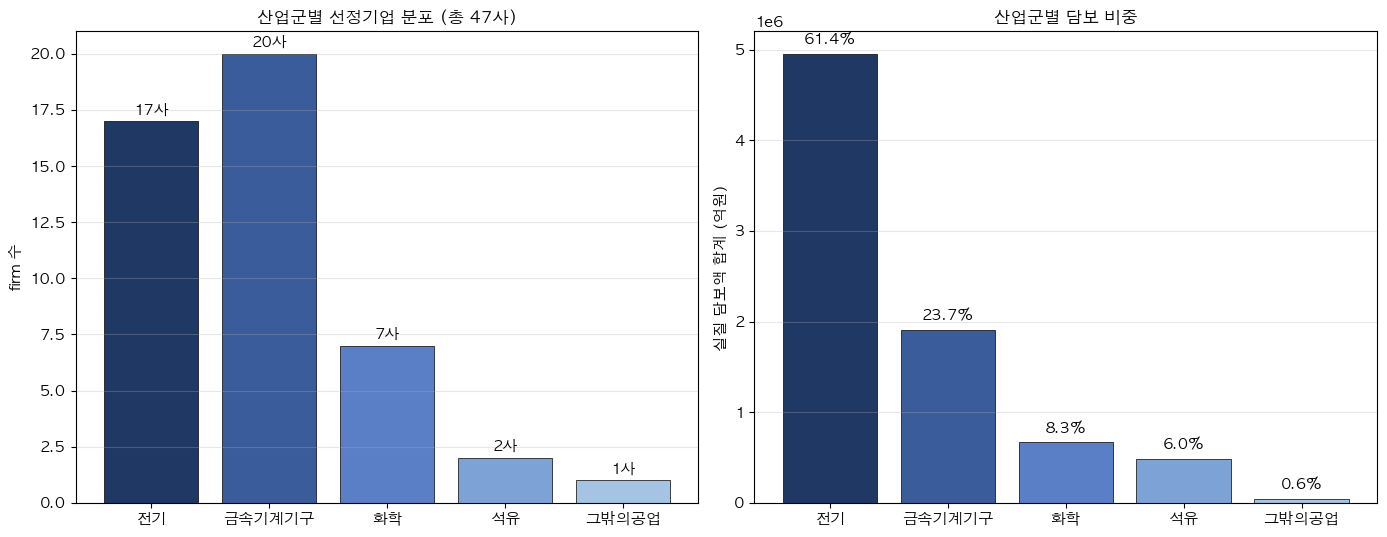

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# 산업별 firm 수
industry_order = industry_summary.index.tolist()
colors = ['#1F3864', '#3a5c9a', '#5b7fc7', '#7da3d6', '#a3c4e3']

ax1.bar(industry_order, industry_summary['firms_count'], color=colors, edgecolor='black', linewidth=0.5)
for i, (idx, v) in enumerate(zip(industry_order, industry_summary['firms_count'])):
    ax1.text(i, v + 0.3, str(int(v)) + '사', ha='center', fontweight='bold')
ax1.set_ylabel('firm 수')
ax1.set_title('산업군별 선정기업 분포 (총 47사)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# 산업별 담보액 합계
ax2.bar(industry_order, industry_summary['total_Ei'], color=colors, edgecolor='black', linewidth=0.5)
for i, (idx, v, p) in enumerate(zip(industry_order, industry_summary['total_Ei'], industry_summary['Ei_share'])):
    ax2.text(i, v + industry_summary['total_Ei'].max() * 0.02, f'{p:.1f}%', ha='center', fontweight='bold')
ax2.set_ylabel('실질 담보액 합계 (억원)')
ax2.set_title('산업군별 담보 비중', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. 핵심 변수 분포 분석

### 4.1 Chart 2 — 탄소집약도(R), 상대탄소집약도(ρ), 전환노력(M) 분포

/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_57322/3100405835.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data_R, labels=industry_order, patch_artist=True, widths=0.6)
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_57322/3100405835.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_rho, labels=industry_order, patch_artist=True, widths=0.6)


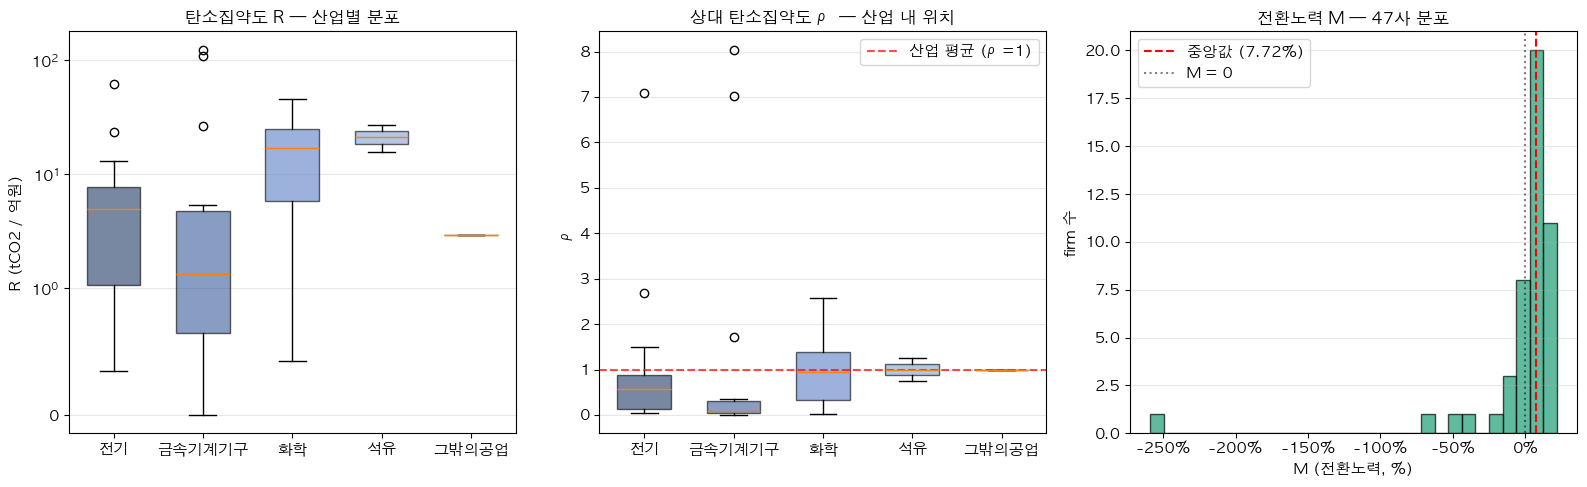

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R 분포 (산업별 boxplot)
data_R = [df[df['산업군']==ind]['R'].values for ind in industry_order]
bp1 = axes[0].boxplot(data_R, labels=industry_order, patch_artist=True, widths=0.6)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel('R (tCO2 / 억원)')
axes[0].set_title('탄소집약도 R — 산업별 분포', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_yscale('symlog', linthresh=1)

# ρ 분포
data_rho = [df[df['산업군']==ind]['rho'].values for ind in industry_order]
bp2 = axes[1].boxplot(data_rho, labels=industry_order, patch_artist=True, widths=0.6)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.7, label='산업 평균 (ρ=1)')
axes[1].set_ylabel('ρ')
axes[1].set_title('상대 탄소집약도 ρ — 산업 내 위치', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# M 분포 (percent)
import matplotlib.ticker as mtick
ax = axes[2]
ax.hist(df['M'], bins=30, color='#1D9E75', edgecolor='black', alpha=0.7)
median_m = df['M'].median()
ax.axvline(median_m, color='red', linestyle='--', label=f'중앙값 ({median_m:.2%})')
ax.axvline(0, color='black', linestyle=':', alpha=0.5, label='M = 0')
ax.set_xlabel('M (전환노력, %)')
ax.set_ylabel('firm 수')
ax.set_title('전환노력 M — 47사 분포', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

### 4.2 Chart 2-1 — 탄소집약도(R) 분포

/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_57322/1265593931.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_R, labels=industry_order, patch_artist=True, widths=0.6)


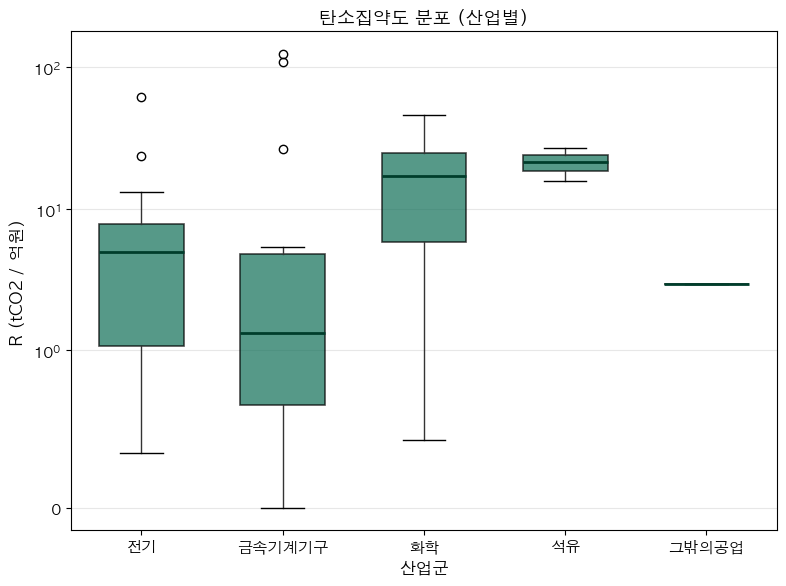

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

# 단일 초록색
color_single = '#0F6E56'

data_R = [df[df['산업군']==ind]['R'].values for ind in industry_order]
bp = ax.boxplot(data_R, labels=industry_order, patch_artist=True, widths=0.6)

for patch in bp['boxes']:
    patch.set_facecolor(color_single)
    patch.set_alpha(0.7)
    patch.set_linewidth(1.2)

# 중앙선, 수염 스타일
for median in bp['medians']:
    median.set_color('#003D2B')
    median.set_linewidth(2)

for whisker in bp['whiskers']:
    whisker.set_color('#333333')
    whisker.set_linewidth(1)

ax.set_ylabel('R (tCO2 / 억원)', fontsize=12, fontweight='bold')
ax.set_xlabel('산업군', fontsize=12, fontweight='bold')
ax.set_title('탄소집약도 분포 (산업별)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.set_yscale('symlog', linthresh=1)

plt.tight_layout()
plt.show()

### 4.3 Chart 2-2 — 전환노력(M) 분포

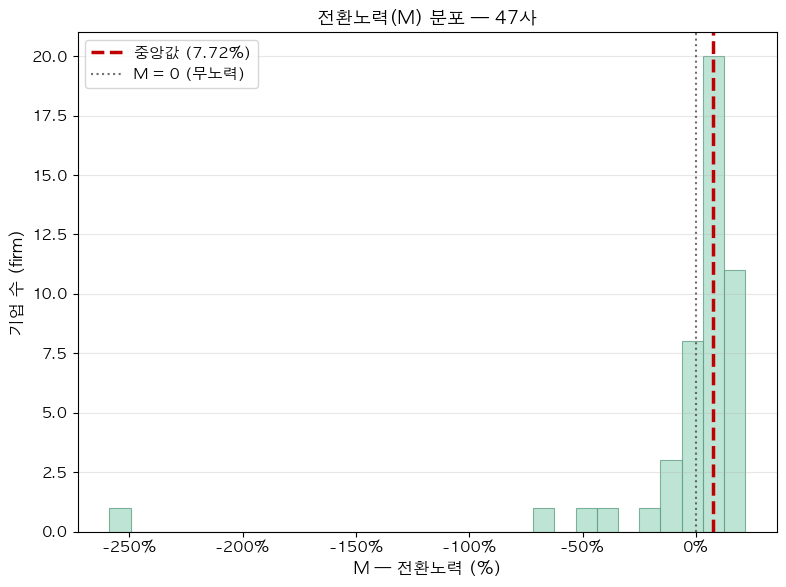

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

# 저채도 초록색 (pastel green)
color_m_light = '#A8DCC7'
edge_color_m = '#5A9B7D'

import matplotlib.ticker as mtick
ax.hist(df['M'], bins=30, color=color_m_light, edgecolor=edge_color_m, alpha=0.75, linewidth=0.8)

# 중앙값
median_m = df['M'].median()
ax.axvline(median_m, color='#C00000', linestyle='--', linewidth=2.5,
           label=f'중앙값 ({median_m:.2%})')

# M = 0
ax.axvline(0, color='#333333', linestyle=':', linewidth=1.5, alpha=0.7, label='M = 0 (무노력)')

ax.set_xlabel('M — 전환노력 (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('기업 수 (firm)', fontsize=12, fontweight='bold')
ax.set_title('전환노력(M) 분포 — 47사', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [8]:
# 음수 M 기업 수 확인
neg_M = df[df['M'] < 0]
print(f"음수 M 기업 수: {len(neg_M)} 사")
# 상세 목록(원하면 주석 해제)
neg_M[['기업명', '산업군', 'M']].sort_values('M')


음수 M 기업 수: 11 사


,기업명,산업군,M
8,기아,금속기계기구,-2.588138
20,에코프로머티,전기,-0.707263
45,코웨이,금속기계기구,-0.528995
32,SK이노베이션,석유,-0.353845
21,엘앤에프,전기,-0.213275
44,LG생활건강,화학,-0.073762
34,롯데케미칼,화학,-0.066482
36,한화솔루션,화학,-0.065928
35,금호석유,화학,-0.040225
28,삼성중공업,금속기계기구,-0.037037


## 5. 4분면 매트릭스 — 탄소 × 전환노력

### 5.1 4분면 정의 및 의미

ESG underwriting 의 핵심 메커니즘은 다음 두 축으로 firm 을 분류한다:

- **X축 (ρ)**: 상대 탄소집약도. 산업 평균 (ρ=1) 대비 어느 정도 탄소를 배출하는가
- **Y축 (M)**: 전환노력. 매년 어느 정도 탄소를 감축하려 노력하는가

임계선 기준:
- ρ = 1.0 (산업 평균)
- M = 중앙값 (≈ 0.077)

보험료 변동 수식 (DF − 1):

$$\Delta\text{보험료}\% = \alpha (\rho - 1) - \beta \cdot M$$


In [49]:
# ─── DF 계산 (이전 α=0.10, β=1.0 / 현재 α=0.05, β=0.8) ───
def compute_df(alpha, beta, rho, M):
    raw = 1 + alpha * (rho - 1) - beta * M
    return np.clip(raw, 0.8, 1.2)

df['DF_old'] = df.apply(lambda r: compute_df(0.10, 1.0, r['rho'], r['M']), axis=1)
df['DF_new'] = df.apply(lambda r: compute_df(0.05, 0.8, r['rho'], r['M']), axis=1)
df['premium_old_pct'] = (df['DF_old'] - 1) * 100
df['premium_new_pct'] = (df['DF_new'] - 1) * 100

# ─── 4분면 분류 ───
rho_thresh = 1.0
M_thresh = df['M'].median()

def quadrant(r):
    if r['rho'] >= rho_thresh and r['M'] >= M_thresh:
        return 'Q1: 고탄소-고노력'
    if r['rho'] < rho_thresh and r['M'] >= M_thresh:
        return 'Q2: 저탄소-고노력'
    if r['rho'] < rho_thresh and r['M'] < M_thresh:
        return 'Q3: 저탄소-저노력'
    return 'Q4: 고탄소-저노력'

df['quadrant'] = df.apply(quadrant, axis=1)

print(f'ρ 임계: {rho_thresh}, M 임계 (중앙값): {M_thresh:.4f}')
print()
print('4분면별 firm 수:')
print(df['quadrant'].value_counts().sort_index())

ρ 임계: 1.0, M 임계 (중앙값): 0.0772

4분면별 firm 수:
quadrant
Q1: 고탄소-고노력     4
Q2: 저탄소-고노력    20
Q3: 저탄소-저노력    15
Q4: 고탄소-저노력     8
Name: count, dtype: int64


### 5.2 Chart 3 — 4분면 매트릭스 산점도 (메인)

- 각 점 = 1개 firm
- 색상 = 4분면 구분
- 크기 = 실질 담보액 (Ei) 비례
- 주요 firm 이름 표시

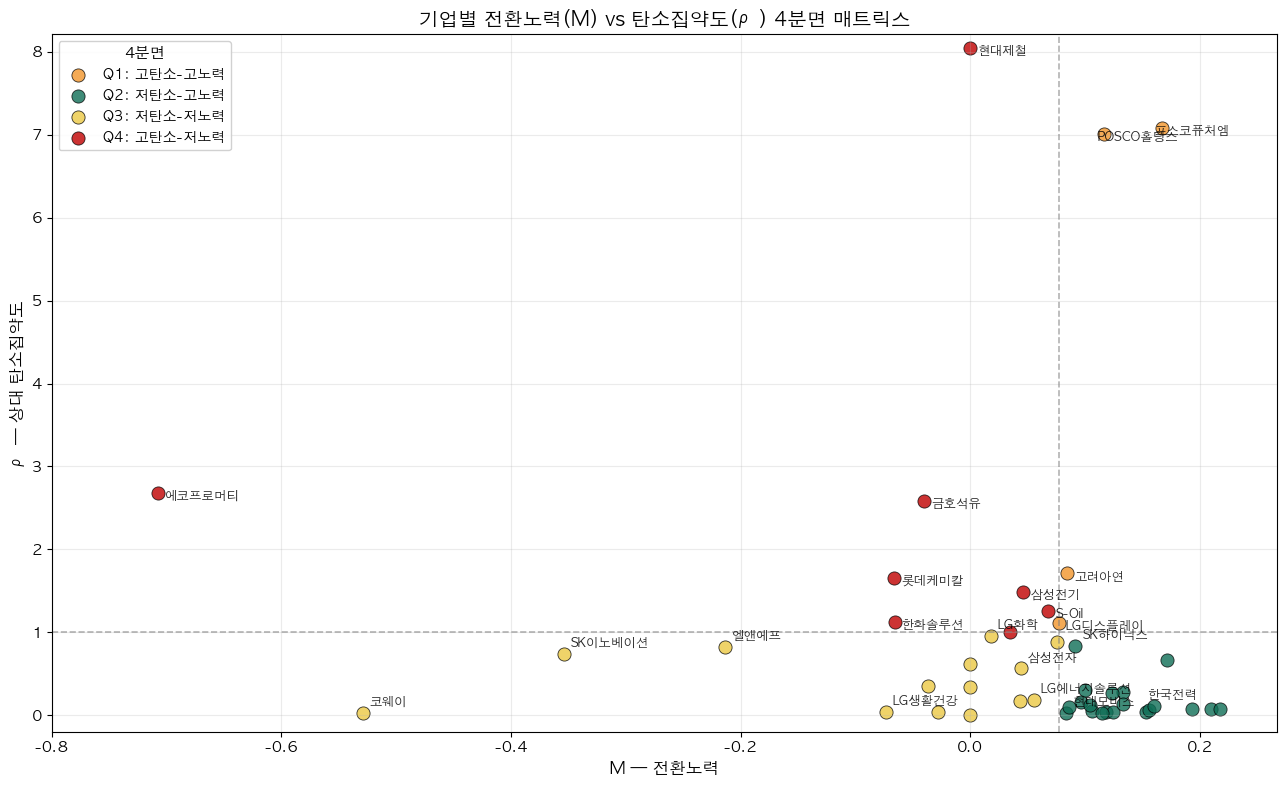

In [50]:
fig, ax = plt.subplots(figsize=(13, 8))

q_colors = {
    'Q1: 고탄소-고노력': '#F2952A',  # top-right
    'Q2: 저탄소-고노력': '#0F6E56',  # bottom-right
    'Q3: 저탄소-저노력': '#EBC944',  # bottom-left
    'Q4: 고탄소-저노력': '#C00000',  # top-left
}

rho_thresh = 1.0
M_thresh = df['M'].median()

def quadrant(r):
    if r['rho'] >= rho_thresh and r['M'] >= M_thresh:
        return 'Q1: 고탄소-고노력'
    if r['rho'] < rho_thresh and r['M'] >= M_thresh:
        return 'Q2: 저탄소-고노력'
    if r['rho'] < rho_thresh and r['M'] < M_thresh:
        return 'Q3: 저탄소-저노력'
    return 'Q4: 고탄소-저노력'

df['quadrant'] = df.apply(quadrant, axis=1)

for q, color in q_colors.items():
    sub = df[df['quadrant'] == q]
    ax.scatter(sub['M'], sub['rho'],
               s=90,
               c=color,
               alpha=0.8,
               edgecolor='black',
               linewidth=0.6,
               marker='o',
               label=q)

ax.axvline(M_thresh, color='gray', linestyle='--', alpha=0.6, linewidth=1.2)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.6, linewidth=1.2)

x_max = max(df['M'].max(), 0)
x_pad = max(0.05, x_max * 0.08)
ax.set_xlim(-0.8, x_max + x_pad)

y_high = df['rho'].quantile(0.99)
y_pad = max(0.05, (y_high - 0) * 0.08)
ax.set_ylim(-0.2, y_high + y_pad)

# 주요 기업 라벨 (겹치지 않는 점 위주로 표시)
candidates = pd.concat([
    df.nlargest(10, 'Ei'),
    df.nlargest(8, 'rho'),
    df.nsmallest(8, 'M'),
    df[df['quadrant'] == 'Q1: 고탄소-고노력'].nlargest(5, 'Ei'),
    df[df['quadrant'] == 'Q2: 저탄소-고노력'].nlargest(5, 'Ei'),
    df[df['quadrant'] == 'Q3: 저탄소-저노력'].nlargest(5, 'Ei'),
    df[df['quadrant'] == 'Q4: 고탄소-저노력'].nlargest(5, 'Ei')
]).drop_duplicates(subset='기업명')

label_positions = []
for _, row in candidates.iterrows():
    x, y = row['M'], row['rho']
    # 축이 가까운 경우에는 한쪽으로 오프셋
    dx = 5 if x < M_thresh else -5
    dy = 5 if y < 1.0 else -5
    if abs(x - M_thresh) < 0.03:
        dx = 5
    if abs(y - 1.0) < 0.05:
        dy = 5

    too_close = any(np.hypot(x - lx, y - ly) < 0.08 for lx, ly in label_positions)
    if too_close:
        continue

    label_positions.append((x, y))
    ax.annotate(row['기업명'],
                xy=(x, y),
                xytext=(dx, dy), textcoords='offset points',
                fontsize=9, alpha=0.85,
                bbox=dict(boxstyle='round,pad=0.2', fc='none', alpha=0.7, edgecolor='none'))

ax.set_xlabel('M — 전환노력', fontsize=12)
ax.set_ylabel('ρ — 상대 탄소집약도', fontsize=12)
ax.set_title('기업별 전환노력(M) vs 탄소집약도(ρ) 4분면 매트릭스', fontsize=14, fontweight='bold')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', title='4분면', fontsize=10, title_fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

### 5.2-1 Chart 3-1 — 담보액(Ei) 기반 점 크기 산점도

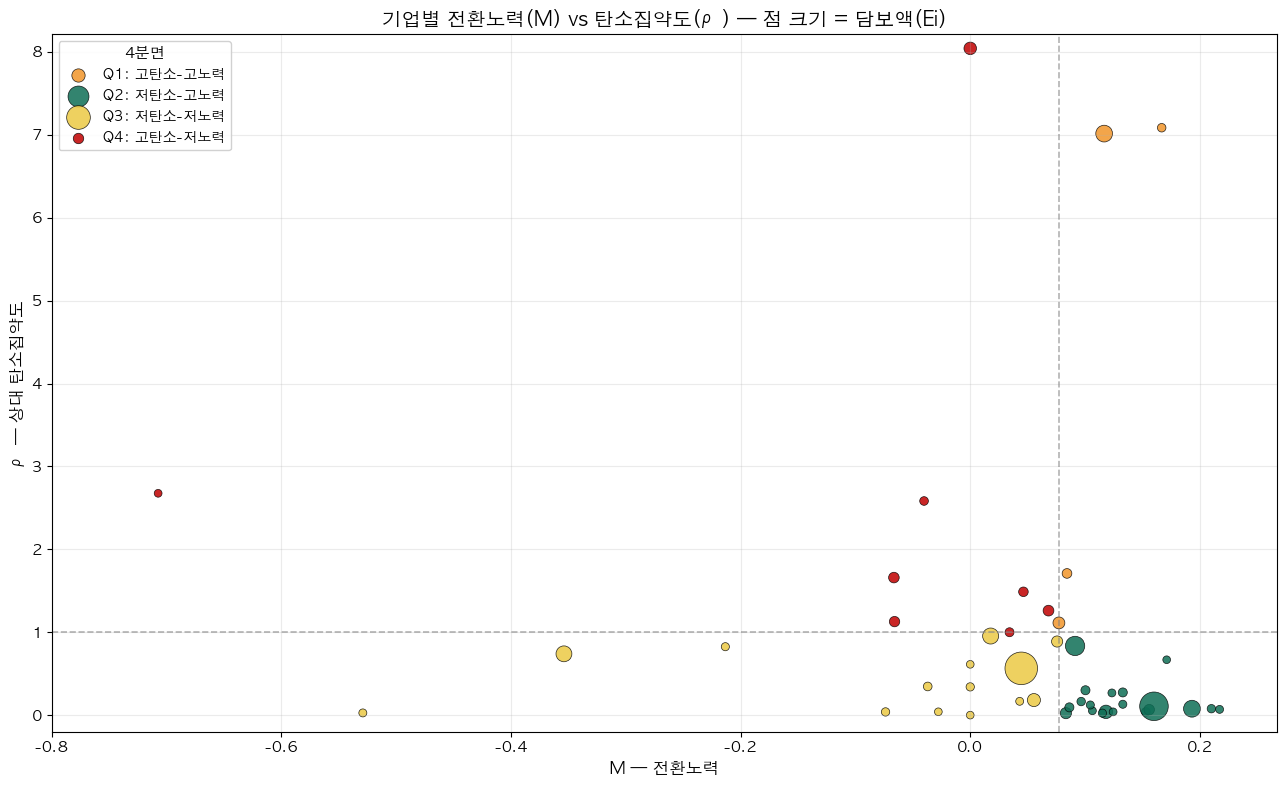

In [51]:
fig, ax = plt.subplots(figsize=(13, 8))
size_scale = 520 / df['Ei'].max()

for q, color in q_colors.items():
    sub = df[df['quadrant'] == q]
    ax.scatter(sub['M'], sub['rho'],
               s=sub['Ei'] * size_scale + 30,
               c=color,
               alpha=0.85,
               edgecolor='black',
               linewidth=0.5,
               marker='o',
               label=q)

ax.axvline(M_thresh, color='gray', linestyle='--', alpha=0.6, linewidth=1.2)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.6, linewidth=1.2)

x_max = max(df['M'].max(), 0)
x_pad = max(0.05, x_max * 0.08)
ax.set_xlim(-0.8, x_max + x_pad)

y_high = df['rho'].quantile(0.99)
y_pad = max(0.05, (y_high - 0) * 0.08)
ax.set_ylim(-0.2, y_high + y_pad)

ax.set_xlabel('M — 전환노력', fontsize=12)
ax.set_ylabel('ρ — 상대 탄소집약도', fontsize=12)
ax.set_title('기업별 전환노력(M) vs 탄소집약도(ρ) — 점 크기 = 담보액(Ei)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.25)
ax.legend(loc='upper left', title='4분면', fontsize=10, title_fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

### 5.3 4분면별 핵심 통계

In [52]:
# 4분면별 요약
quad_summary = df.groupby('quadrant').agg(
    firms=('기업명', 'count'),
    avg_R=('R', 'mean'),
    avg_rho=('rho', 'mean'),
    avg_M=('M', 'mean'),
    total_Ei=('Ei', 'sum'),
    DF_old=('DF_old', 'mean'),
    DF_new=('DF_new', 'mean'),
).round(4)

quad_summary['premium_old_%'] = ((quad_summary['DF_old'] - 1) * 100).round(2)
quad_summary['premium_new_%'] = ((quad_summary['DF_new'] - 1) * 100).round(2)

print('=' * 90)
print('4분면별 요약 — 보험료 차등 시그널')
print('=' * 90)
print(quad_summary[['firms', 'avg_rho', 'avg_M', 'DF_old', 'DF_new', 'premium_old_%', 'premium_new_%']])

4분면별 요약 — 보험료 차등 시그널
             firms  avg_rho   avg_M  DF_old  DF_new  premium_old_%  \
quadrant                                                             
Q1: 고탄소-고노력      4   4.2302  0.1112  1.0802  1.0707           8.02   
Q2: 저탄소-고노력     20   0.1737  0.1338  0.8097  0.8534         -19.03   
Q3: 저탄소-저노력     15   0.3846 -0.2391  1.0008  1.0227           0.08   
Q4: 고탄소-저노력      8   2.4795 -0.0914  1.0920  1.0719           9.20   

             premium_new_%  
quadrant                    
Q1: 고탄소-고노력           7.07  
Q2: 저탄소-고노력         -14.66  
Q3: 저탄소-저노력           2.27  
Q4: 고탄소-저노력           7.19  


## 6. 기업 클러스터링 (K-means)

(ρ, M) 2차원 공간에서 K-means 클러스터링으로 firm 유형을 자동 분류한다.

In [53]:
# ─── 정규화 후 K-means ───
features = df[['rho', 'M']].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

K = 4  # 클러스터 수
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(features_scaled)

# 각 클러스터 특성
cluster_stats = df.groupby('cluster').agg(
    firms=('기업명', 'count'),
    avg_rho=('rho', 'mean'),
    avg_M=('M', 'mean'),
    avg_R=('R', 'mean'),
    total_Ei=('Ei', 'sum'),
).round(3).sort_values('avg_rho')

print('=' * 70)
print('K-means 클러스터 (K=4) 특성')
print('=' * 70)
print(cluster_stats)

K-means 클러스터 (K=4) 특성
         firms  avg_rho  avg_M   avg_R  total_Ei
cluster                                         
2            1    0.043 -2.588   0.661    216326
0           37    0.414  0.082   5.273   6644508
3            6    1.418 -0.318  20.453    551712
1            3    7.380  0.094  98.135    654256


### 6.1 Chart 4 — 클러스터링 결과 시각화

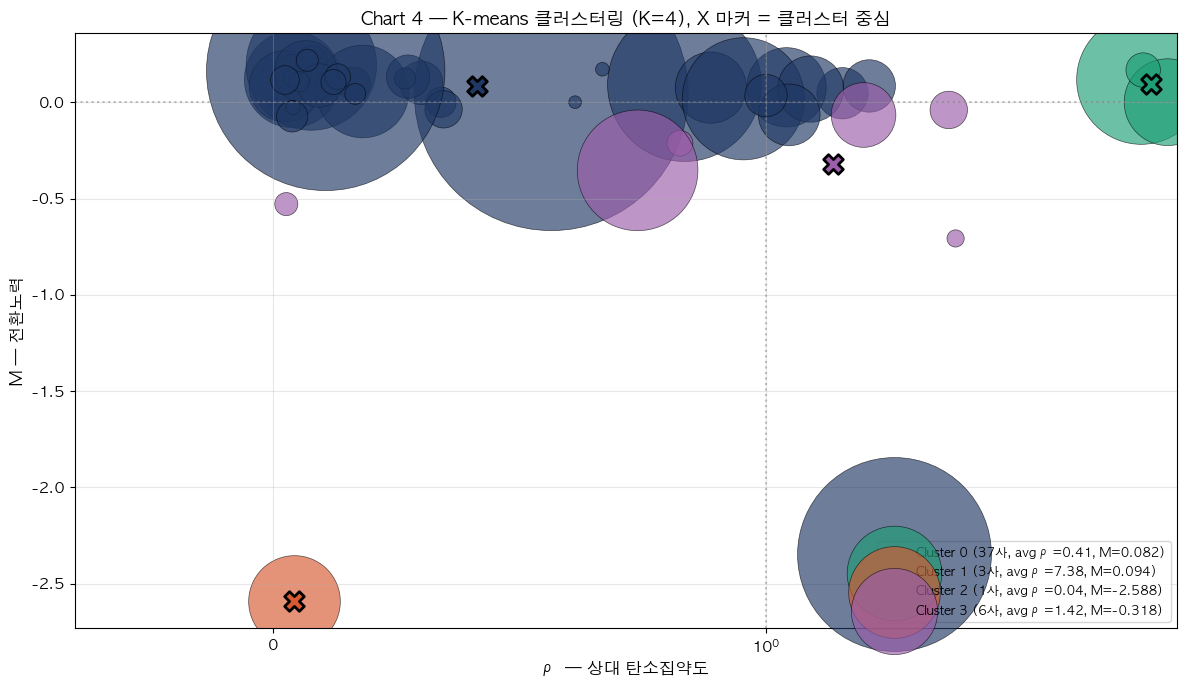

In [54]:
fig, ax = plt.subplots(figsize=(12, 7))

cluster_colors = ['#1F3864', '#1D9E75', '#D85A30', '#9C5DAA']

for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    ax.scatter(sub['rho'], sub['M'],
               s=sub['Ei'] / 50 + 30,
               c=cluster_colors[c], alpha=0.65,
               edgecolor='black', linewidth=0.5,
               label=f'Cluster {c} ({len(sub)}사, avg ρ={sub["rho"].mean():.2f}, M={sub["M"].mean():.3f})')

# Cluster 중심 표시 (역변환)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
for i, (cx, cy) in enumerate(centers):
    ax.scatter(cx, cy, marker='X', s=200, c=cluster_colors[i], edgecolor='black', linewidth=2, zorder=5)

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(1.0, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('ρ — 상대 탄소집약도', fontsize=12)
ax.set_ylabel('M — 전환노력', fontsize=12)
ax.set_title(f'Chart 4 — K-means 클러스터링 (K={K}), X 마커 = 클러스터 중심', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xscale('symlog', linthresh=1)

plt.tight_layout()
plt.show()

## 7. α/β 파라미터 변경 효과 분석

### 7.1 변경 의도 및 가상 철강회사 예시 재확인

**문제 제기**: 기존 (α=0.10, β=1.0) 에서는 노력하는 dirty firm 도 여전히 할증을 받음.

**해결책**: α를 절반으로 (0.10→0.05) 줄여 "현재 상태 페널티" 약화, β는 소폭만 줄여 (1.0→0.8) "노력 보상" 비중 상대적으로 강화.

In [64]:
# 가상 철강사 시나리오
print('=' * 70)
print('가상 철강사 — ρ=2.0, M=0.05 (산업 평균의 2배 배출, 5% 감축노력)')
print('=' * 70)
for label, (a, b) in [('이전 (α=0.10, β=1.0)', (0.10, 1.0)),
                       ('현재 (α=0.05, β=1.0)', (0.05, 1))]:
    df_val = compute_df(a, b, 2.0, 0.05)
    pen_val = (df_val - 1) * 100
    print(f'{label:>25}: DF = {df_val:.4f},  보험료 = {pen_val:+.2f}% (할증)')

# β/α 비율
print()
print(f'β/α 비율: 이전 = 10.0,  현재 = 16.0 (+60% — 노력 비중 강화)')

가상 철강사 — ρ=2.0, M=0.05 (산업 평균의 2배 배출, 5% 감축노력)
       이전 (α=0.10, β=1.0): DF = 1.0500,  보험료 = +5.00% (할증)
       현재 (α=0.05, β=1.0): DF = 1.0000,  보험료 = +0.00% (할증)

β/α 비율: 이전 = 10.0,  현재 = 16.0 (+60% — 노력 비중 강화)


### 7.2 임계 노력 (Break-Even M) — 노력으로 할증을 상쇄하기까지

DF = 1 (할증·할인 없음) 을 만들기 위해 필요한 최소 전환노력 $M^*$:

$$\alpha(\rho - 1) = \beta \cdot M^* \quad \Rightarrow \quad M^* = \frac{\alpha (\rho - 1)}{\beta}$$

- 이전: $M^*_{old} = 0.10 \cdot (\rho - 1) / 1.0 = 0.10 (\rho - 1)$
- 현재: $M^*_{new} = 0.05 \cdot (\rho - 1) / 0.8 = 0.0625 (\rho - 1)$

→ **현재 파라미터는 같은 ρ 에서 break-even 도달에 필요한 노력이 약 37.5% 감소**

### 7.3 Chart 5 — 임계 노력 곡선 (Break-Even M Curve)

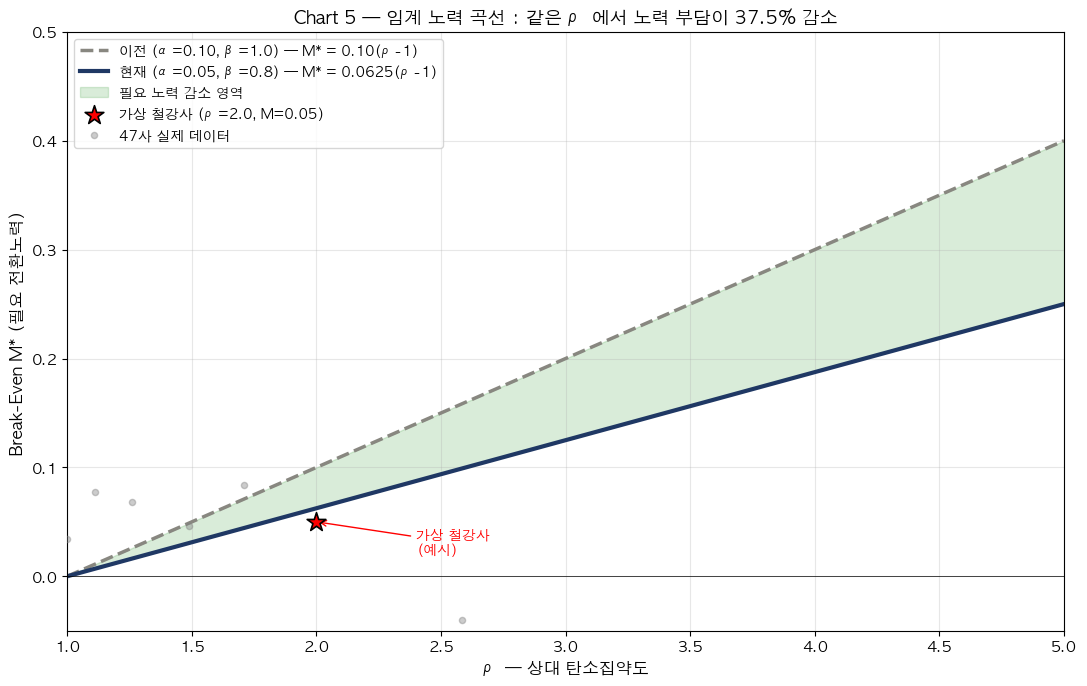

In [65]:
fig, ax = plt.subplots(figsize=(11, 7))

rho_range = np.linspace(1, 5, 100)
M_star_old = 0.10 * (rho_range - 1) / 1.0
M_star_new = 0.05 * (rho_range - 1) / 0.8

ax.plot(rho_range, M_star_old, color='#888780', linewidth=2.5, linestyle='--',
        label='이전 (α=0.10, β=1.0) — M* = 0.10(ρ-1)')
ax.plot(rho_range, M_star_new, color='#1F3864', linewidth=3,
        label='현재 (α=0.05, β=0.8) — M* = 0.0625(ρ-1)')

ax.fill_between(rho_range, M_star_new, M_star_old, alpha=0.15, color='green', label='필요 노력 감소 영역')

# 가상 철강사 표시
ax.scatter([2.0], [0.05], s=200, c='red', marker='*', edgecolor='black', linewidth=1.2,
           zorder=5, label='가상 철강사 (ρ=2.0, M=0.05)')
ax.annotate('가상 철강사\n(예시)', xy=(2.0, 0.05), xytext=(2.4, 0.02),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red', fontweight='bold')

# 실제 firm 들 산점도 (overlay)
ax.scatter(df['rho'], df['M'], s=20, c='gray', alpha=0.4, zorder=3, label='47사 실제 데이터')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('ρ — 상대 탄소집약도', fontsize=12)
ax.set_ylabel('Break-Even M* (필요 전환노력)', fontsize=12)
ax.set_title('Chart 5 — 임계 노력 곡선 : 같은 ρ 에서 노력 부담이 37.5% 감소', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(1, 5)
ax.set_ylim(-0.05, 0.5)

plt.tight_layout()
plt.show()

### 7.4 Chart 6 — 4분면별 보험료 변화 (이전 vs 현재)

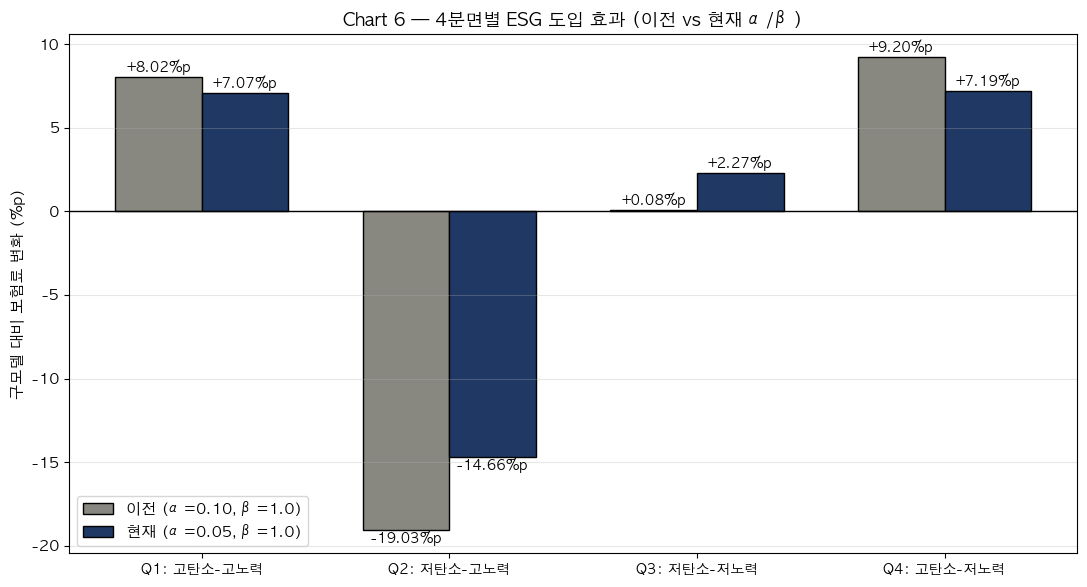

In [67]:
fig, ax = plt.subplots(figsize=(11, 6))

quadrants = ['Q1: 고탄소-고노력', 'Q2: 저탄소-고노력', 'Q3: 저탄소-저노력', 'Q4: 고탄소-저노력']
old_vals = [quad_summary.loc[q, 'premium_old_%'] for q in quadrants]
new_vals = [quad_summary.loc[q, 'premium_new_%'] for q in quadrants]

x = np.arange(len(quadrants))
w = 0.35

bars1 = ax.bar(x - w/2, old_vals, w, label='이전 (α=0.10, β=1.0)', color='#888780', edgecolor='black')
bars2 = ax.bar(x + w/2, new_vals, w, label='현재 (α=0.05, β=1.0)', color='#1F3864', edgecolor='black')

for b, v in zip(bars1, old_vals):
    ax.text(b.get_x() + b.get_width()/2, v + (0.3 if v >= 0 else -0.8),
            f'{v:+.2f}%p', ha='center', fontsize=10, fontweight='bold')
for b, v in zip(bars2, new_vals):
    ax.text(b.get_x() + b.get_width()/2, v + (0.3 if v >= 0 else -0.8),
            f'{v:+.2f}%p', ha='center', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(quadrants, fontsize=10)
ax.set_ylabel('구모델 대비 보험료 변화 (%p)', fontsize=11)
ax.set_title('Chart 6 — 4분면별 ESG 도입 효과 (이전 vs 현재 α/β)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.5 Chart 7 — 47사 firm-level DF 변화 산점도

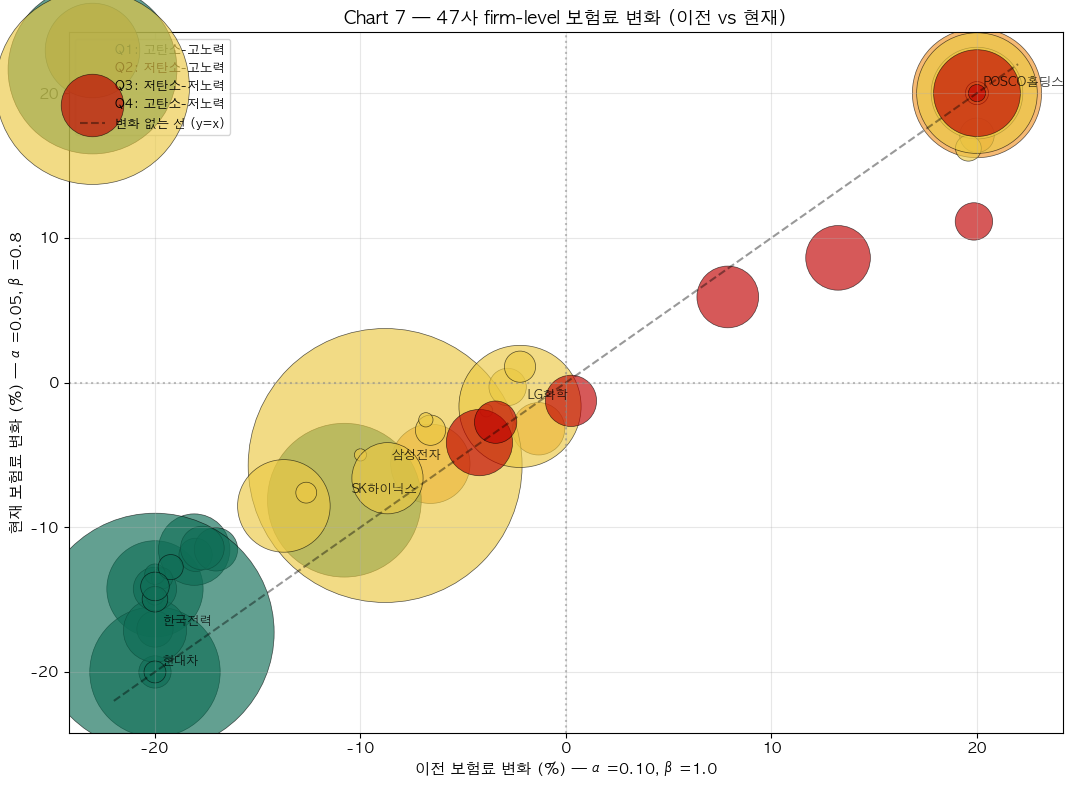

In [60]:
fig, ax = plt.subplots(figsize=(11, 8))

q_colors = {
    'Q1: 고탄소-고노력': '#F2952A',
    'Q2: 저탄소-고노력': '#0F6E56',
    'Q3: 저탄소-저노력': '#EBC944',
    'Q4: 고탄소-저노력': '#C00000',
}

if 'quadrant' not in df.columns:
    rho_thresh = 1.0
    M_thresh = df['M'].median()

    def quadrant(r):
        if r['rho'] >= rho_thresh and r['M'] >= M_thresh:
            return 'Q1: 고탄소-고노력'
        if r['rho'] < rho_thresh and r['M'] >= M_thresh:
            return 'Q2: 저탄소-고노력'
        if r['rho'] < rho_thresh and r['M'] < M_thresh:
            return 'Q3: 저탄소-저노력'
        return 'Q4: 고탄소-저노력'

    df['quadrant'] = df.apply(quadrant, axis=1)

# 산점도: x = DF_old, y = DF_new
for q, color in q_colors.items():
    sub = df[df['quadrant'] == q]
    ax.scatter(sub['premium_old_pct'], sub['premium_new_pct'],
               s=sub['Ei'] / 50 + 30,
               c=color, alpha=0.65, edgecolor='black', linewidth=0.5,
               label=q)

# 45도 선 (변화 없는 firm)
max_val = max(df['premium_old_pct'].max(), df['premium_new_pct'].max()) + 2
min_val = min(df['premium_old_pct'].min(), df['premium_new_pct'].min()) - 2
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label='변화 없는 선 (y=x)')

# 0 라인
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)

# 주요 firm 라벨
for _, row in df.nlargest(6, 'Ei').iterrows():
    ax.annotate(row['기업명'],
                xy=(row['premium_old_pct'], row['premium_new_pct']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8)

ax.set_xlabel('이전 보험료 변화 (%) — α=0.10, β=1.0', fontsize=11)
ax.set_ylabel('현재 보험료 변화 (%) — α=0.05, β=0.8', fontsize=11)
ax.set_title('Chart 7 — 47사 firm-level 보험료 변화 (이전 vs 현재)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. t=0 손익 구조 변화 — 구모델 vs 신모델 (현재 α/β)

ESG 모델 도입 시점 (t=0) 에 구모델 영업손익 (`영_구`) 과 신모델 영업손익 (`영_신`) 의 차이를 firm-level 로 비교.

In [61]:
# 시트의 영_구, 영_신 활용
df['profit_change'] = df['영_신'] - df['영_구']

print('=' * 70)
print('t=0 영업손익 — 구모델 vs 신모델 합계')
print('=' * 70)
print(f"구모델 영업손익 합계: {df['영_구'].sum():>+10,.1f} 억")
print(f"신모델 영업손익 합계: {df['영_신'].sum():>+10,.1f} 억")
print(f"신-구 차이 (Δ영)    : {df['profit_change'].sum():>+10,.1f} 억")
print()
print('Δ영 가장 큰 firm (신모델로 개선):')
print(df.nlargest(5, 'profit_change')[['기업명', '산업군', 'rho', 'M', '영_구', '영_신', 'profit_change']].round(1))
print()
print('Δ영 가장 작은 firm (신모델로 악화):')
print(df.nsmallest(5, 'profit_change')[['기업명', '산업군', 'rho', 'M', '영_구', '영_신', 'profit_change']].round(1))

t=0 영업손익 — 구모델 vs 신모델 합계
구모델 영업손익 합계:     +421.6 억
신모델 영업손익 합계:     -570.6 억
신-구 차이 (Δ영)    :     -992.2 억

Δ영 가장 큰 firm (신모델로 개선):
        기업명     산업군  rho    M   영_구   영_신  profit_change
1    SK하이닉스      전기  0.8  0.1  19.8  38.1           18.4
8        기아  금속기계기구  0.0 -2.6  14.1  27.3           13.2
15     현대제철  금속기계기구  8.0  0.0  12.6  16.9            4.3
21     엘앤에프      전기  0.8 -0.2   0.5   3.8            3.3
32  SK이노베이션      석유  0.7 -0.4  17.8  20.3            2.5

Δ영 가장 작은 firm (신모델로 악화):
     기업명     산업군  rho    M   영_구    영_신  profit_change
37  한국전력      전기  0.1  0.2  47.6 -401.2         -448.8
0   삼성전자      전기  0.6  0.0  62.9 -182.2         -245.1
7    현대차  금속기계기구  0.1  0.2  28.6  -34.9          -63.5
4   LG전자      전기  0.0  0.1   7.7  -51.9          -59.7
31  LG화학      화학  1.0  0.0  65.4   14.8          -50.5


### 8.1 Chart 8 — firm-level 영업손익 변화 분포

/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_57322/332897675.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_57322/332897675.py:29: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.savefig('part1_chart8_profit_change.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


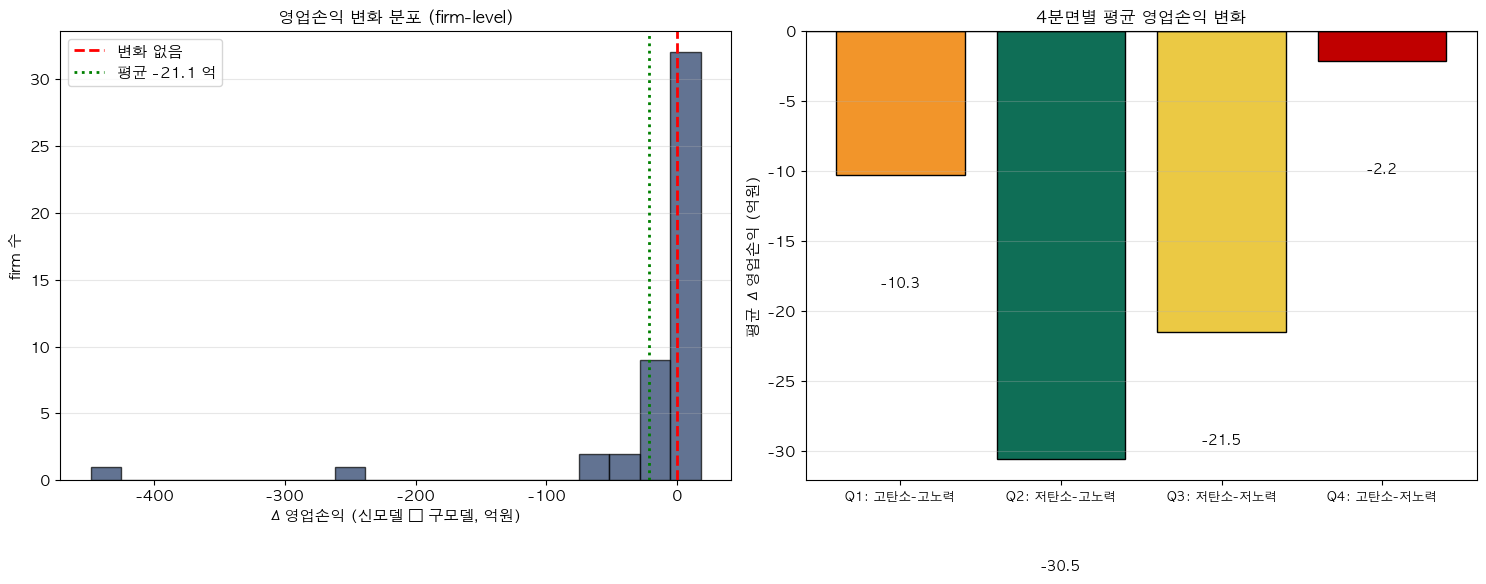

✓ part1_chart8_profit_change.png 저장


In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 좌: 영업손익 변화 히스토그램
ax1.hist(df['profit_change'], bins=20, color='#1F3864', edgecolor='black', alpha=0.7)
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='변화 없음')
ax1.axvline(df['profit_change'].mean(), color='green', linestyle=':', linewidth=2,
            label=f"평균 {df['profit_change'].mean():+.1f} 억")
ax1.set_xlabel('Δ영업손익 (신모델 − 구모델, 억원)')
ax1.set_ylabel('firm 수')
ax1.set_title('영업손익 변화 분포 (firm-level)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# 우: 4분면별 평균 영업손익 변화
quad_profit = df.groupby('quadrant')['profit_change'].mean().reindex(quadrants)
colors_q = [q_colors[q] for q in quadrants]
bars = ax2.bar(range(len(quadrants)), quad_profit, color=colors_q, edgecolor='black')
for b, v in zip(bars, quad_profit):
    ax2.text(b.get_x() + b.get_width()/2, v + (5 if v >= 0 else -8),
             f'{v:+.1f}', ha='center', fontsize=10, fontweight='bold')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(range(len(quadrants)))
ax2.set_xticklabels(quadrants, fontsize=9)
ax2.set_ylabel('평균 Δ영업손익 (억원)')
ax2.set_title('4분면별 평균 영업손익 변화', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('part1_chart8_profit_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ part1_chart8_profit_change.png 저장')

## 9. 보험영업손익 양수 vs 음수 기업 비교

- 보험영업손익(`profit_change`)이 양수인 기업과 음수인 기업을 구분하여 비교합니다.
- 양수/음수 기업 수, 평균 ρ, 평균 M, 평균 담보액(Ei)을 표로 정리하고, 양수/음수 기업 수를 막대 그래프로 시각화합니다.

보험영업손익 양수/음수 기업 비교
             firms  avg_rho  avg_M      avg_Ei   sum_Ei  avg_profit_change
profit_sign                                                               
양수               8    1.516 -0.445  184128.625  1473029              5.443
음수              39    0.869  0.061  169071.103  6593773            -26.557

양수 기업 상위 5개
    기업명      rho         M     Ei  profit_change
 SK하이닉스 0.834662  0.091307 611583      18.362244
     기아 0.042818 -2.588138 216326      13.248638
   현대제철 8.042211  0.000000 193611       4.278085
   엘앤에프 0.825510 -0.213275  15734       3.295322
SK이노베이션 0.739511 -0.353845 375787       2.478631

음수 기업 상위 5개
 기업명      rho        M      Ei  profit_change
한국전력 0.106704 0.160016 1471705    -448.845864
삼성전자 0.564467 0.044444 1943346    -245.061239
 현대차 0.077597 0.193110  439416     -63.493730
LG전자 0.039453 0.118200  238903     -59.669116
LG화학 0.954195 0.017773  385366     -50.532367


/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_57322/2783847454.py:59: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


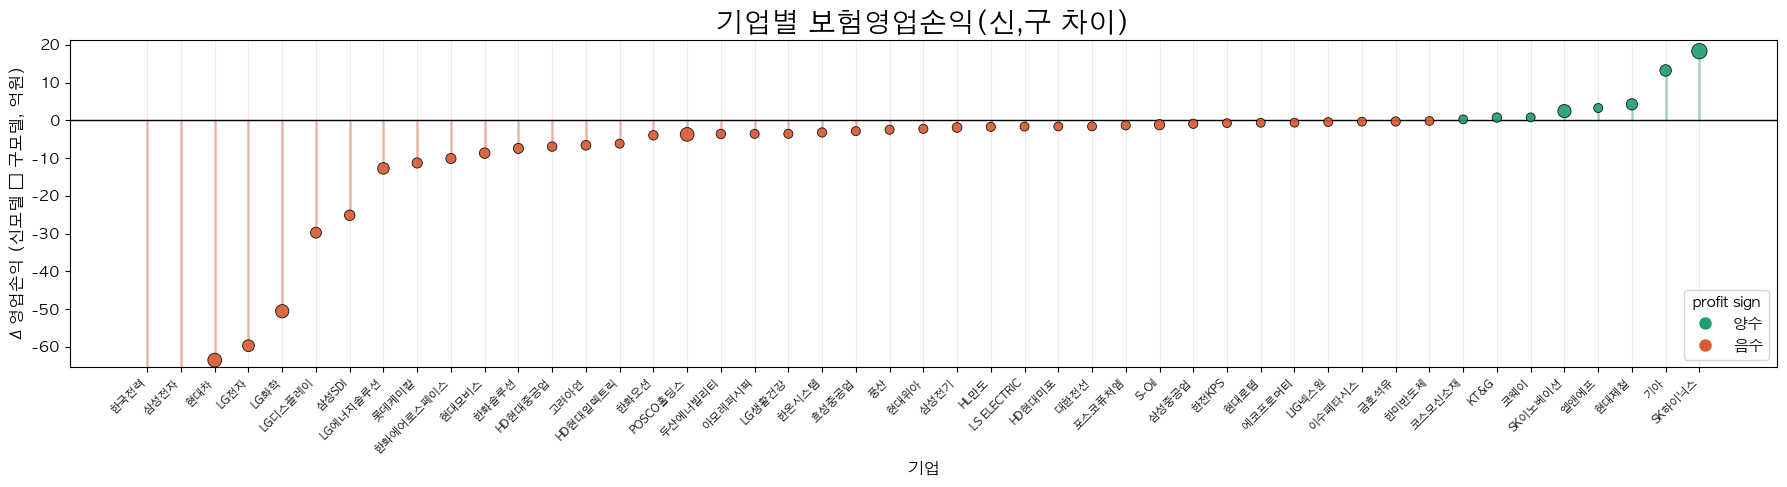

In [63]:
# 보험영업손익 양수/음수 그룹 비교
profit_groups = df.assign(
    profit_sign=lambda d: np.where(d['profit_change'] >= 0, '양수', '음수')
)

summary_profit = profit_groups.groupby('profit_sign').agg(
    firms=('기업명', 'count'),
    avg_rho=('rho', 'mean'),
    avg_M=('M', 'mean'),
    avg_Ei=('Ei', 'mean'),
    sum_Ei=('Ei', 'sum'),
    avg_profit_change=('profit_change', 'mean')
).round(3)

print('보험영업손익 양수/음수 기업 비교')
print(summary_profit)

# 그룹별 상위/하위 기업 목록
positive_top = profit_groups[profit_groups['profit_sign'] == '양수'].nlargest(5, 'profit_change')[['기업명', 'rho', 'M', 'Ei', 'profit_change']]
negative_top = profit_groups[profit_groups['profit_sign'] == '음수'].nsmallest(5, 'profit_change')[['기업명', 'rho', 'M', 'Ei', 'profit_change']]

print('\n양수 기업 상위 5개')
print(positive_top.to_string(index=False))
print('\n음수 기업 상위 5개')
print(negative_top.to_string(index=False))

# 시각화: 기업명과 profit_change 를 함께 보여주는 수평 점 차트
plot_df = profit_groups.sort_values('profit_change').reset_index(drop=True)
plot_df['x_pos'] = np.arange(len(plot_df))
plot_df['color'] = plot_df['profit_sign'].map({'양수': '#1D9E75', '음수': '#D85A30'})
plot_df['size'] = plot_df['Ei'] / plot_df['Ei'].max() * 260 + 40

fig, ax = plt.subplots(figsize=(18, 5))
ax.vlines(plot_df['x_pos'], ymin=0, ymax=plot_df['profit_change'],
          color=plot_df['color'], alpha=0.35, linewidth=2)
ax.scatter(plot_df['x_pos'], plot_df['profit_change'], s=plot_df['size'],
           c=plot_df['color'], edgecolor='black', linewidth=0.6, alpha=0.9, zorder=3)

ax.set_xticks(plot_df['x_pos'])
label_names = plot_df['기업명'].tolist()
ax.set_xticklabels(label_names, fontsize=8, rotation=45, ha='right')
ax.axhline(0, color='black', linestyle='-', linewidth=1)

x_min = plot_df['profit_change'].quantile(0.05) - 3
x_max = plot_df['profit_change'].max() + 3
ax.set_ylim(x_min, x_max)

ax.set_xlabel('기업', fontsize=12)
ax.set_ylabel('Δ영업손익 (신모델 − 구모델, 억원)', fontsize=12)
ax.set_title('기업별 보험영업손익(신,구 차이)', fontsize=20, fontweight='bold')
ax.grid(alpha=0.25, axis='x')

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='양수', markerfacecolor='#1D9E75', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='음수', markerfacecolor='#D85A30', markersize=10)
]
ax.legend(handles=legend_handles, title='profit sign', loc='lower right', fontsize=11, title_fontsize=11)

plt.tight_layout()
plt.show()